# Detecting Data Drift with Summary Statistics

See [`docs/04-detecting-data-drift.md`](../docs/04-detecting-data-drift.md#summary-statistics) for the
concept notes this notebook is based on.

This is the cheapest and simplest way to check for drift: compare key statistics (mean, median,
standard deviation, quantiles, category proportions, min/max range) between a **reference** window
(what the model was trained/validated on) and a **current** window (a recent production batch).

All four notebooks in this folder analyze the exact same synthetic `reference`/`current` pair from
[`src/drift_dataset.py`](../src/drift_dataset.py), so results are directly comparable across techniques.

## Load the shared reference/current dataset

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import (
    CATEGORICAL_COLUMNS,
    COLUMN_DRIFT_GROUND_TRUTH,
    NUMERICAL_COLUMNS,
    make_reference_and_current,
)

pd.set_option("display.width", 120)

reference, current = make_reference_and_current(seed=42)
print("reference:", reference.shape, " current:", current.shape)
reference.head()

reference: (5000, 6)  current: (2000, 6)


,channel,product_category,basket_size,discount_pct,unit_price,customer_age
0,in_store,electronics,21.102831,0.031317,17.104594,32.639729
1,in_store,grocery,63.178040,0.062780,22.418914,46.994313
2,online,home,51.468098,0.173390,15.736280,43.558738
3,in_store,electronics,46.992552,0.189024,16.649926,52.330196
4,in_store,electronics,53.157178,0.080097,18.866577,44.449209


## Numerical features: reference vs. current statistics

A simple, interpretable table: mean, standard deviation, median, and the 5th/95th percentiles for
each numerical feature, in both windows.

In [2]:
def numeric_summary(ref, cur, columns):
    rows = []
    for col in columns:
        r, c = ref[col], cur[col]
        rows.append({
            "feature": col,
            "ref_mean": r.mean(), "cur_mean": c.mean(),
            "ref_std": r.std(), "cur_std": c.std(),
            "ref_median": r.median(), "cur_median": c.median(),
            "ref_p05": r.quantile(0.05), "cur_p05": c.quantile(0.05),
            "ref_p95": r.quantile(0.95), "cur_p95": c.quantile(0.95),
        })
    return pd.DataFrame(rows).set_index("feature").round(3)

numeric_summary(reference, current, NUMERICAL_COLUMNS)

,ref_mean,cur_mean,ref_std,cur_std,ref_median,cur_median,ref_p05,cur_p05,ref_p95,cur_p95
feature,,,,,,,,,,
basket_size,45.018,57.924,15.200,22.162,43.208,55.297,23.337,27.521,73.340,97.726
discount_pct,0.092,0.112,0.061,0.066,0.081,0.101,0.016,0.026,0.210,0.240
unit_price,21.600,21.978,8.963,9.321,19.940,20.262,10.354,10.683,37.866,38.765
customer_age,39.810,36.862,11.545,58.172,39.494,39.631,20.152,19.417,59.283,60.375


## A simple alerting rule: is the current mean within 2 standard deviations of reference?

This is the kind of lightweight check the article describes: flag a feature whenever its current
mean falls outside `reference_mean ± 2 * reference_std`. It reacts to a shifted center of mass, but
says nothing about shape changes that leave the mean roughly where it was.

In [3]:
def two_sigma_flags(ref, cur, columns, n_std=2):
    rows = []
    for col in columns:
        lo = ref[col].mean() - n_std * ref[col].std()
        hi = ref[col].mean() + n_std * ref[col].std()
        cur_mean = cur[col].mean()
        rows.append({
            "feature": col,
            "reference_band": f"[{lo:.2f}, {hi:.2f}]",
            "current_mean": round(cur_mean, 2),
            "flagged": not (lo <= cur_mean <= hi),
        })
    return pd.DataFrame(rows).set_index("feature")

two_sigma_flags(reference, current, NUMERICAL_COLUMNS)

,reference_band,current_mean,flagged
feature,,,
basket_size,"[14.62, 75.42]",57.92,False
discount_pct,"[-0.03, 0.21]",0.11,False
unit_price,"[3.67, 39.53]",21.98,False
customer_age,"[16.72, 62.90]",36.86,False


Notice that **nothing gets flagged here** — not even `basket_size`, which we already know has
drifted (its mean moved by nearly 13 units). The reference standard deviation for `basket_size` is
large (15.2), so a ±2-sigma band is wide enough to absorb the shift. This is the two-sigma rule's
main failure mode: it's only as sensitive as the reference variance happens to allow, and a feature
with naturally high spread can drift substantially while still looking "within range" on this check
alone. `02_statistical_tests.ipynb` and `03_distance_metrics.ipynb` both catch this same
`basket_size` shift clearly — worth keeping in mind before trusting a single summary-statistic rule.

## Categorical features: value-count proportions

For categorical features, the equivalent of "summary statistics" is comparing the share of each
category between the two windows, and watching for categories that only exist in one of them.

In [4]:
def categorical_summary(ref, cur, column):
    categories = sorted(set(ref[column]) | set(cur[column]))
    table = pd.concat(
        [
            ref[column].value_counts(normalize=True).reindex(categories, fill_value=0).rename("reference"),
            cur[column].value_counts(normalize=True).reindex(categories, fill_value=0).rename("current"),
        ],
        axis=1,
    ).round(4)
    table["abs_diff"] = (table["current"] - table["reference"]).abs().round(4)
    table["new_in_current"] = table["reference"] == 0
    return table

for col in CATEGORICAL_COLUMNS:
    print(f"--- {col} ---")
    display(categorical_summary(reference, current, col))

--- channel ---


,reference,current,abs_diff,new_in_current
channel,,,,
in_store,0.851,0.5545,0.2965,False
online,0.149,0.4455,0.2965,False


--- product_category ---


,reference,current,abs_diff,new_in_current
product_category,,,,
apparel,0.2458,0.2160,0.0298,False
beauty,0.0984,0.0805,0.0179,False
electronics,0.3004,0.2530,0.0474,False
grocery,0.2134,0.1690,0.0444,False
home,0.1420,0.1420,0.0000,False
online_exclusive,0.0000,0.1395,0.1395,True


## Feature range compliance

A min-max range check: what share of current values falls outside a domain-expected range? This is
good at catching **data quality bugs** (like the corrupted `customer_age` values injected into
`current`), but it will *not* catch `basket_size`'s drift, since those values stay well within a
"plausible basket size" range even though the whole distribution shifted.

In [5]:
expected_ranges = {
    "basket_size": (0, None),
    "discount_pct": (0, 1),
    "unit_price": (0, None),
    "customer_age": (18, 90),
}

def range_compliance(cur, ranges):
    rows = []
    for col, (lo, hi) in ranges.items():
        mask = pd.Series(False, index=cur.index)
        if lo is not None:
            mask |= cur[col] < lo
        if hi is not None:
            mask |= cur[col] > hi
        rows.append({
            "feature": col,
            "expected_range": f"[{lo if lo is not None else '-inf'}, {hi if hi is not None else 'inf'}]",
            "share_out_of_range": mask.mean(),
        })
    return pd.DataFrame(rows).set_index("feature").round(4)

range_compliance(current, expected_ranges)

,expected_range,share_out_of_range
feature,,
basket_size,"[0, inf]",0.0000
discount_pct,"[0, 1]",0.0000
unit_price,"[0, inf]",0.0000
customer_age,"[18, 90]",0.0125


Note the split: `customer_age` gets flagged (real data quality bug — the injected `-1`/`-5`/`-999`
values), while `basket_size` does not, despite having genuinely drifted. Range checks and drift
checks answer different questions — see
[`docs/02-data-drift-vs-related-concepts.md`](../docs/02-data-drift-vs-related-concepts.md#data-drift-vs-data-quality).

## Visual comparison: overlaid distributions

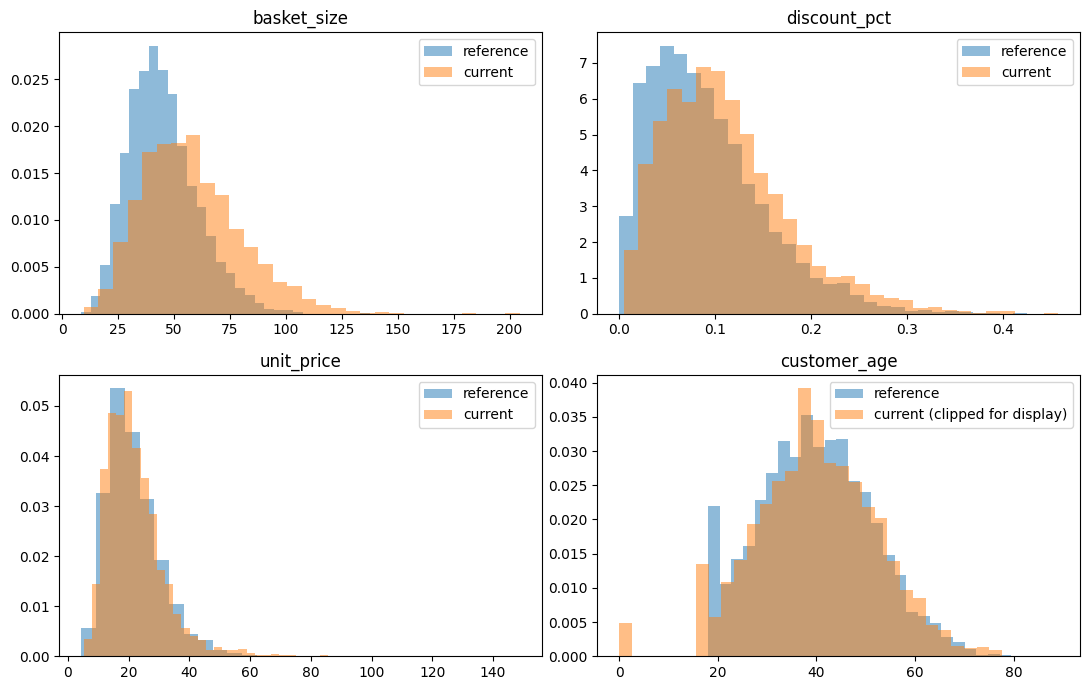

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
plot_cols = ["basket_size", "discount_pct", "unit_price"]
# customer_age has extreme injected outliers (-999); clip just for plotting readability
clipped_age_cur = current["customer_age"].clip(lower=0, upper=100)

for ax, col in zip(axes.flat[:3], plot_cols):
    ax.hist(reference[col], bins=30, alpha=0.5, density=True, label="reference")
    ax.hist(current[col], bins=30, alpha=0.5, density=True, label="current")
    ax.set_title(col)
    ax.legend()

ax = axes.flat[3]
ax.hist(reference["customer_age"], bins=30, alpha=0.5, density=True, label="reference")
ax.hist(clipped_age_cur, bins=30, alpha=0.5, density=True, label="current (clipped for display)")
ax.set_title("customer_age")
ax.legend()

fig.tight_layout()
plt.show()

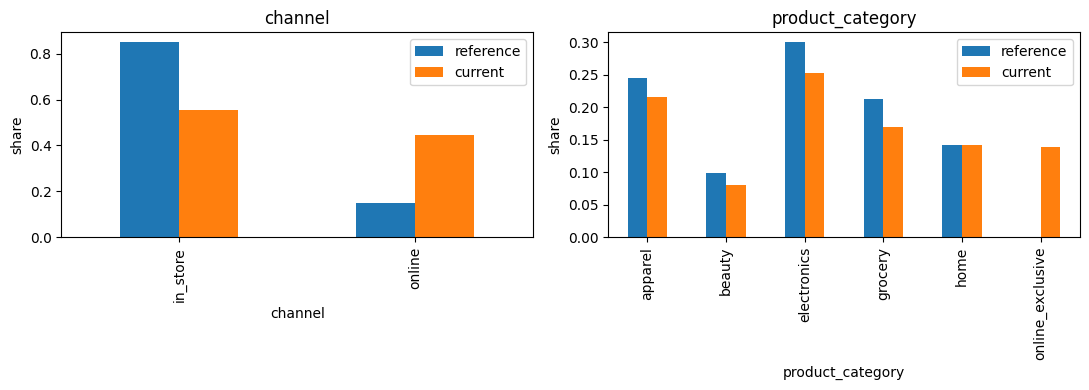

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, CATEGORICAL_COLUMNS):
    table = categorical_summary(reference, current, col)[["reference", "current"]]
    table.plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("share")
fig.tight_layout()
plt.show()

## When to use summary statistics

- **Good first pass / always-on baseline**: cheap to compute, easy to explain to non-technical
  stakeholders, and works well when you already have domain expectations about a feature's mean,
  median, or quantiles.
- **Weak spot**: watching many features this way gets noisy, and — as `basket_size` showed above —
  a rule this simple can miss a real, substantial shift whenever the reference data already has
  high natural variance. The mean moving is necessary but not sufficient for a mean-based rule to
  fire; it also has to move further than the reference noise floor.
- **Range compliance** is a data-quality tool more than a drift tool: it's excellent at catching
  corrupted or out-of-bounds values, but blind to distribution shifts that stay in range.
- Pairs well with statistical tests or distance metrics (`02_statistical_tests.ipynb`,
  `03_distance_metrics.ipynb`) for a more rigorous verdict on "how different is different enough."

## Answer key

What this synthetic scenario was built to demonstrate for each column:

In [8]:
pd.Series(COLUMN_DRIFT_GROUND_TRUTH, name="ground_truth").to_frame()

,ground_truth
channel,drift
product_category,drift
basket_size,drift
discount_pct,borderline
unit_price,none
customer_age,data_quality
